Saving Mall_Customers.csv to Mall_Customers (4).csv
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


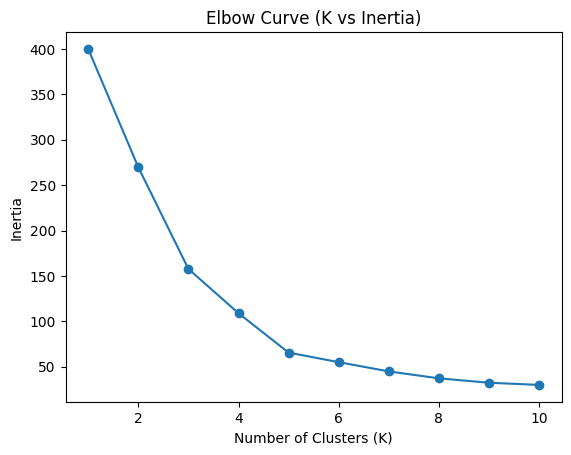


K-Means Results:
Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


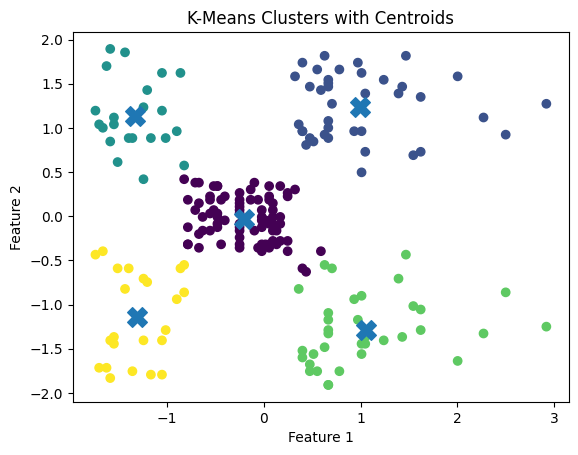


Cluster Means:
         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


In [7]:
# ==========================================
# SCENARIO 1: K-MEANS CLUSTERING
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Upload dataset (Colab)
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Elbow Method (K vs Inertia)
# -----------------------------
inertia = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Curve (K vs Inertia)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

# -----------------------------
# Apply K-Means
# -----------------------------
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels
df['Cluster'] = labels

# -----------------------------
# Evaluation
# -----------------------------
print("\nK-Means Results:")
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, labels))

# -----------------------------
# Scatter Plot + Centroids
# -----------------------------
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=200)

plt.title("K-Means Clusters with Centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# -----------------------------
# Cluster Means (FIXED)
# -----------------------------
print("\nCluster Means:")
print(df.groupby('Cluster').mean(numeric_only=True))

Saving Mall_Customers.csv to Mall_Customers (5).csv
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

GMM Results:
Log Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


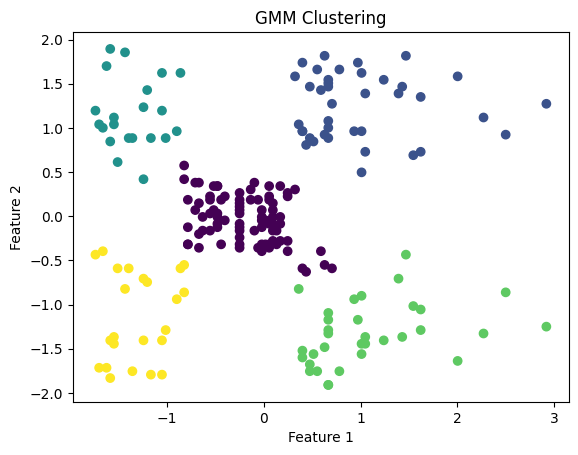

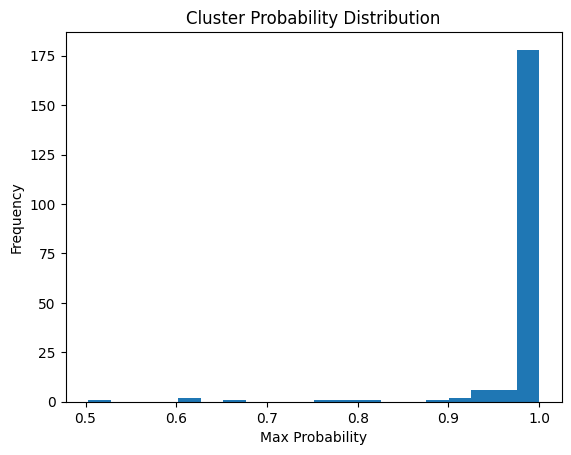

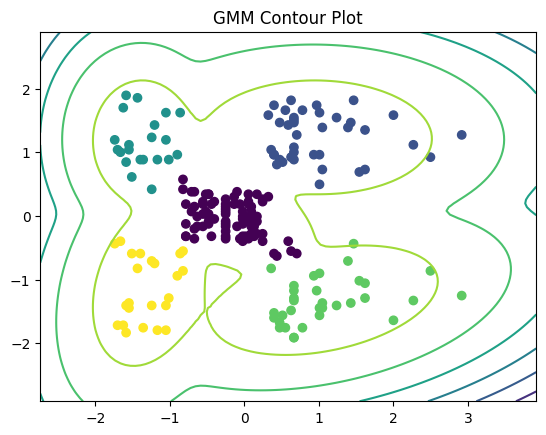


Sample Probabilities:
[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [8]:
# ==========================================
# SCENARIO 2: GMM CLUSTERING
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Upload dataset (Colab)
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Apply GMM
# -----------------------------
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

# -----------------------------
# Evaluation
# -----------------------------
print("\nGMM Results:")
print("Log Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, labels))

# -----------------------------
# Scatter Plot
# -----------------------------
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("GMM Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# -----------------------------
# Probability Distribution
# -----------------------------
plt.hist(np.max(probs, axis=1), bins=20)
plt.title("Cluster Probability Distribution")
plt.xlabel("Max Probability")
plt.ylabel("Frequency")
plt.show()

# -----------------------------
# GMM Contour Plot
# -----------------------------
x = np.linspace(X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1, 100)
y = np.linspace(X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1, 100)
X_grid, Y_grid = np.meshgrid(x, y)

grid = np.array([X_grid.ravel(), Y_grid.ravel()]).T
Z = gmm.score_samples(grid)
Z = Z.reshape(X_grid.shape)

plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)

plt.title("GMM Contour Plot")
plt.show()

# -----------------------------
# Show Probabilities
# -----------------------------
print("\nSample Probabilities:")
print(probs[:5])

Saving Mall_Customers.csv to Mall_Customers (6).csv
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

--- COMPARISON RESULTS ---

K-Means:
Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091

GMM:
Log Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


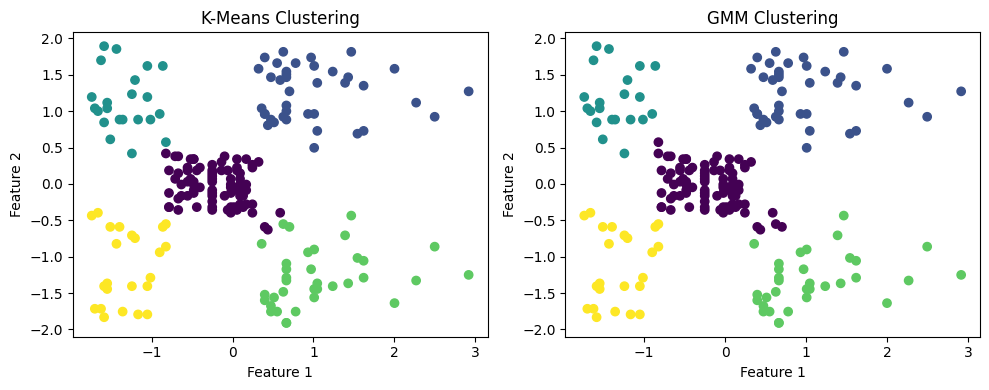

In [9]:
# ==========================================
# COMPARISON: K-MEANS vs GMM
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Upload dataset (Colab)
from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_csv("Mall_Customers.csv")
print(df.head())

# Select features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# K-MEANS
# -----------------------------
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# -----------------------------
# GMM
# -----------------------------
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

gmm_labels = gmm.predict(X_scaled)

# -----------------------------
# Evaluation Comparison
# -----------------------------
print("\n--- COMPARISON RESULTS ---")

print("\nK-Means:")
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))

print("\nGMM:")
print("Log Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, gmm_labels))

# -----------------------------
# Visualization Comparison
# -----------------------------
plt.figure(figsize=(10,4))

# K-Means Plot
plt.subplot(1,2,1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# GMM Plot
plt.subplot(1,2,2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels)
plt.title("GMM Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.tight_layout()
plt.show()